In [39]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

print("Entorno preparado")

Entorno preparado


In [40]:
# Número de dispositivos médicos simulados

n_samples = 10000

# Para que los resultados sean siempre reproducibles
np.random.seed(42)

print("Número de productos simulados:", n_samples)

Número de productos simulados: 10000


In [41]:
# Generación de parámetros del proceso de fabricación

temperature = np.random.normal(
    loc=75,
    scale=5,
    size=n_samples
)

pressure = np.random.normal(
    loc=4,
    scale=0.5,
    size=n_samples
)

cycle_time = np.random.normal(
    loc=35,
    scale=5,
    size=n_samples
)

machine_speed = np.random.normal(
    loc=120,
    scale=15,
    size=n_samples
)

vibration = np.random.normal(
    loc=0.05,
    scale=0.02,
    size=n_samples
)

humidity = np.random.normal(
    loc=45,
    scale=5,
    size=n_samples
)

print("Variables de fabricación generadas correctamente")

Variables de fabricación generadas correctamente


In [42]:
# Simulación de probabilidad de fallo más realista

defect_probability = (
    0.05
    + 0.25*(temperature > 82)
    + 0.30*(vibration > 0.08)
    + 0.25*(cycle_time < 30)
    + 0.15*(pressure > 4.8)
)

random_values = np.random.random(n_samples)

defect = (random_values < defect_probability)

defect = defect.astype(int)

print("Productos defectuosos:", defect.sum())

Productos defectuosos: 1448


In [43]:
data = pd.DataFrame({

    "temperature_C": temperature,
    "pressure_bar": pressure,
    "cycle_time_min": cycle_time,
    "machine_speed_rpm": machine_speed,
    "vibration_mm": vibration,
    "humidity_percent": humidity,
    "defect": defect

})

data.head()

,temperature_C,pressure_bar,cycle_time_min,machine_speed_rpm,vibration_mm,humidity_percent,defect
0,77.483571,3.660753,36.741431,90.291420,0.040563,45.491031,0
1,74.308678,3.847250,36.416618,104.175215,0.070254,44.679459,0
2,78.238443,3.701309,30.317401,111.194574,0.046036,49.758954,0
3,82.615149,4.055209,37.897921,122.245034,0.051811,52.664156,0
4,73.829233,4.598589,27.549587,135.362435,0.064348,48.434235,1


In [44]:
data.to_csv(
    "../data/manufacturing_data.csv",
    index=False
)

print("Dataset guardado correctamente")

Dataset guardado correctamente


In [45]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temperature_C      10000 non-null  float64
 1   pressure_bar       10000 non-null  float64
 2   cycle_time_min     10000 non-null  float64
 3   machine_speed_rpm  10000 non-null  float64
 4   vibration_mm       10000 non-null  float64
 5   humidity_percent   10000 non-null  float64
 6   defect             10000 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 547.0 KB


In [46]:
data.describe()


,temperature_C,pressure_bar,cycle_time_min,machine_speed_rpm,vibration_mm,humidity_percent,defect
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,74.989320,4.006767,34.937686,119.886428,0.050131,45.008731,0.144800
std,5.017312,0.500505,4.957091,15.067306,0.020008,5.048675,0.351917
min,55.387999,2.071812,16.724567,53.015942,-0.035908,24.211331,0.000000
25%,71.637047,3.668995,31.499240,109.580807,0.036719,41.615380,0.000000
50%,74.987025,4.007923,34.971159,119.844266,0.050191,45.041120,0.000000
75%,78.355404,4.346932,38.319487,130.185457,0.063677,48.454161,0.000000
max,94.631189,6.239542,53.458123,175.917500,0.120731,63.726896,1.000000


In [47]:
data['defect'].value_counts()

defect
0    8552
1    1448
Name: count, dtype: int64

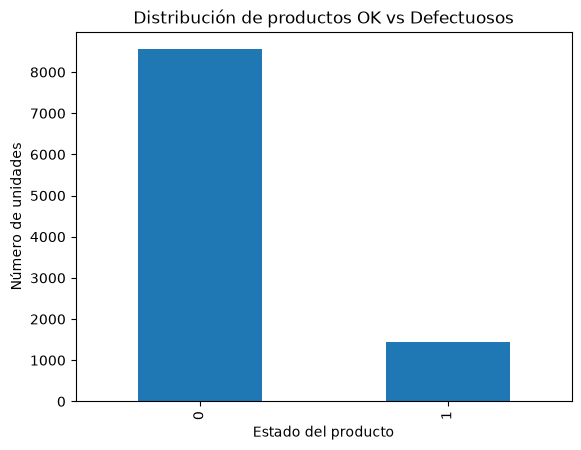

In [48]:
import matplotlib.pyplot as plt

data["defect"].value_counts().plot(kind="bar")

plt.xlabel("Estado del producto")
plt.ylabel("Número de unidades")
plt.title("Distribución de productos OK vs Defectuosos")

plt.show()

In [49]:
data["defect"].value_counts()

defect
0    8552
1    1448
Name: count, dtype: int64

In [50]:
data.groupby("defect").mean()

,temperature_C,pressure_bar,cycle_time_min,machine_speed_rpm,vibration_mm,humidity_percent
defect,,,,,,
0,74.760900,4.001992,35.298067,119.878809,0.049284,45.027171
1,76.338385,4.034966,32.809250,119.931426,0.055132,44.899821


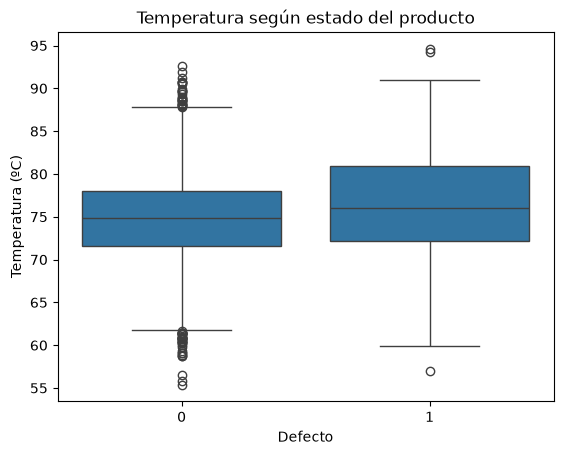

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x="defect",
    y="temperature_C",
    data=data
)

plt.title("Temperatura según estado del producto")
plt.xlabel("Defecto")
plt.ylabel("Temperatura (ºC)")

plt.show()

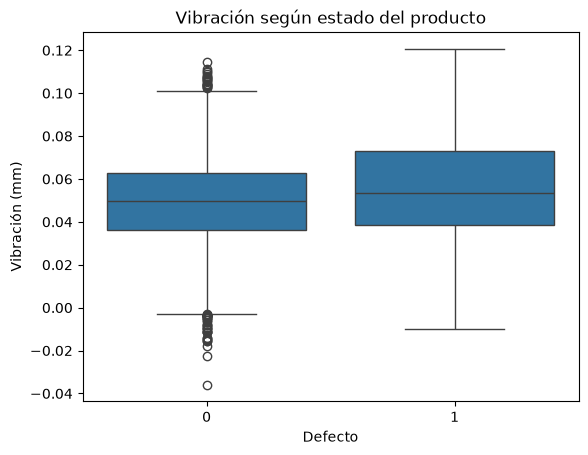

In [52]:
sns.boxplot(
    x="defect",
    y="vibration_mm",
    data=data
)

plt.title("Vibración según estado del producto")
plt.xlabel("Defecto")
plt.ylabel("Vibración (mm)")

plt.show()

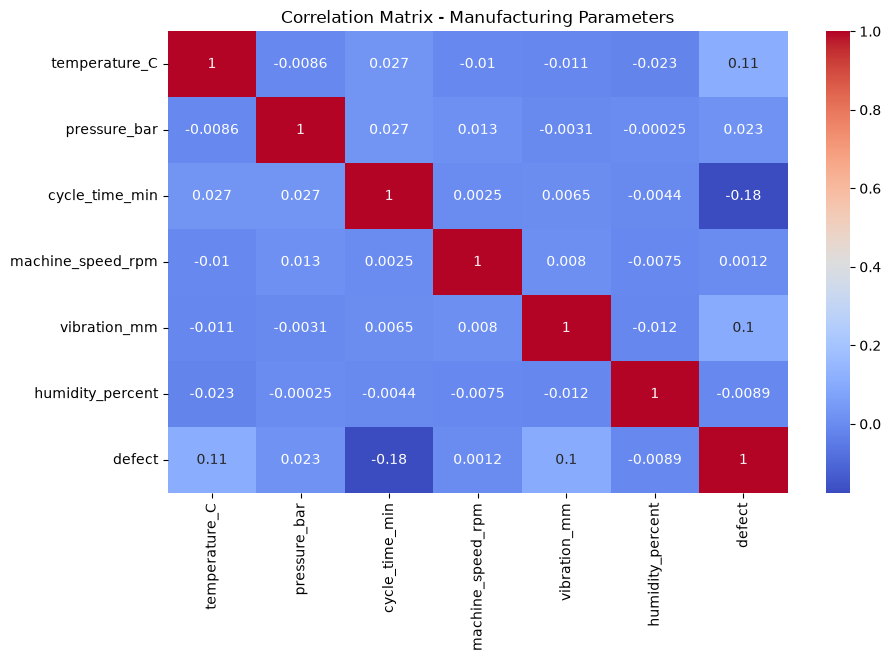

In [53]:
plt.figure(figsize=(10,6))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix - Manufacturing Parameters")

plt.show()

In [54]:
# Separación de variables

X = data.drop("defect", axis=1)

y = data["defect"]

print("Variables de entrada:")
print(X.columns)

print("\nVariable objetivo:")
print(y.name)

Variables de entrada:
Index(['temperature_C', 'pressure_bar', 'cycle_time_min', 'machine_speed_rpm',
       'vibration_mm', 'humidity_percent'],
      dtype='str')

Variable objetivo:
defect
